In [27]:
import yaml, torch, sys
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch.nn.functional as F
import random as random
import re
import torch, json, random, os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

from types import SimpleNamespace
#add more packages here
sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device

In [5]:
import importlib
import utils.train_model
importlib.reload(utils.train_model)
from utils.train_model import run_experiment, set_seed, get_device

In [6]:

sys.path.insert(0, '../../')
from utils.train_model import set_seed, get_device

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_01.yaml') as f:
    config.update(yaml.safe_load(f))
    
    

def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

config = to_namespace(config)

set_seed(config.seed)
device = get_device()

RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)


data_dir = Path("./EX_01/Raw/")



[device] using cpu


# Context.

This is the first experiment of the first epic, whose purpose is to establish a baseline. The purpose of EX_01 is to establish the most minimum baseline version of this paper. It is expected that performance will be very poor, but we want to validate and be sure that what we wish to do is doable, before we start optimizing.

First, what we are learning mathematically is a optimal mask over a glyph, which both maximally reduces the probabilty of recognition before the application of a blur, and maximizes the probability of recognition after the application of this blur. For the purposes of this paper, we restrict the possible blurs to blurs that may be modeled by a human hand holding a camera of relatively standard quality - the vaugeness of this description allows for a sufficiently robust set of possible blurs. 

# Hypothesis

Thus, our formal hypothesis is as follows:

A 3-layer "standard" CNN can achieve a higher combined score than a manual approach. Here, "combined score" can be represented by the following mathematical function:

$\Delta-VIS(b, i) = -\alpha * p(x) + \beta * p(y)$

Where $x$ is confidence prior to the blur, and $y$ is posterior, and a $(b, i)$ pair is a background and hidden image pair. 

# Implementation 

$p(x)$ is measured by a simple classifer trained on the MNIST dataset. It consists of two convolutional layers and three linear layers, and achieves an accuracy of 99% after 10 epochs. All layer weights and frozen and will be used as is throughout all experiments unless mentioned otherwise. $p$ is the confidence of the model that the given image is depicting the correct number. 

The "standard CNN" will be a classifier with a single convolutional "block", consisting of a 

# Data

Each background is a sythentically created gradient between two random colors, in a 28x28p image. Each image will be a randomly selected item of the MNIST dataset.

For right now, we're just going to plop the mnist image (in the code called "i" or "image") over the gradient background (in the code called "b" or "background"), forming a 4-channel image (called "c" or "comp" in the code). Future experiments should expand on this by learning other combinations. 

# Notes

It is expected that some $(b, i)$ pairs will work better than others, and we hope we will have sufficient time for the project to also build a classifer to determine this, or else incorporate it in our given model. A useful extension, which is unlikely to be completed in our work, is to automatically build the best possible background. 

# Code

## MNIST Classifer
Here we build the function m_classify, and ensure it works correctly:

In [7]:
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    comp = b + i.expand_as(b) #[3, 28, 28]
    return comp


class ex01b(Dataset):
    def __init__(self, batch_size, transform=None):
        self.pairings = pd.read_csv(Path(config.csv_path))
        self.gradients_dir = Path(config.grad_dir)
        self.transform = transform if transform is not None else transforms.ToTensor()
        self.mnist     = datasets.MNIST('../../data/', train=True, download=False,
                                        transform=transforms.ToTensor())

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann = self.pairings.iloc[idx]
        b_img_path =  ann["gradient_path"]
        b = self.transform(Image.open(b_img_path).convert("RGB")) 
        i, lab = self.mnist[int(ann["mnist_idx"])]

        if config.combination_type == "alpha":
            comp = alpha_combine(b, i)
        else:
            comp = additive_combine(b, i)
        return comp.clamp(0, 1), lab

ex01b_trainset = ex01b(batch_size = config.batch_size)
ex01b_trainloader = DataLoader(ex01b_trainset, batch_size=config.batch_size, shuffle=True)
ex01b_valloader = DataLoader(ex01b_trainset, batch_size=config.batch_size, shuffle=True)


In [38]:
def ex01b_loss_fn(batch, model, mode="train", **kwargs):
    imgs, labels = batch
    logits = model(imgs)
    loss = nn.CrossEntropyLoss()(logits, labels)

    if mode == "val":
        acc = (logits.argmax(1) == labels).float().mean().item()
        return {"val_loss": loss.item(), "val_acc": acc}
    return loss


# ── RUN ───────────────────────────────────────────────────────────────────────
ex01b_info = {
    "exp_id":      "EX_01b",
    "epochs":      3,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/B",
    "log_dir":     "logs/B",
    "seed":        42,
    "notes": "a 3 channel mnist classifer. comb_type shouldn't matter"
}

b_model = LeNet3channel()
optimizer = torch.optim.Adam(b_model.parameters(), lr=config.lr)

if True:
    b_model = LeNet3channel().to(device)
    b_model.load_state_dict(torch.load('Model/B/EX_01b_final.pt', map_location=device, weights_only=True))
    b_model.eval()

else:
    run_experiment(
        model=b_model,
        optimizer=optimizer,
        loss_fn=ex01b_loss_fn,
        train_loader=ex01b_trainloader,
        val_loader=ex01b_valloader,
        config=ex01b_info,
        log_to=ex01b_info["log_to"],
    )
    
# returns conf, predicted
def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred

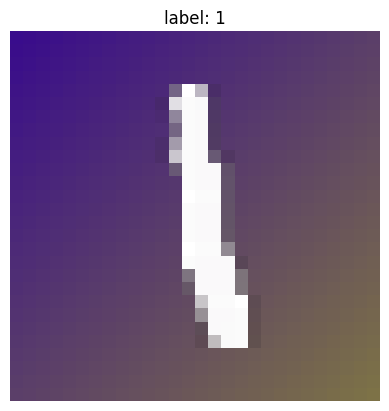

true: 1, predicted: 1, conf: 1.0000


In [44]:


idx = random.randint(0,10)
digit, label = ex01b_trainset[idx]


# show it
plt.imshow(digit.permute(1, 2, 0))
plt.title(f"label: {label}")
plt.axis("off")
plt.show()

digit = digit.unsqueeze(0).to(device)  # (1, 3, 28, 28)
conf, predicted = m_classify_3d_with_conf(digit, label)
print(f"true: {label}, predicted: {predicted.item()}, conf: {conf[0].item():.4f}")

Seems decent. Let's build the "manual" method. I personally don't know hardly anything about what a good mask would look like, so let's just use a random one. Surely almost anything intentional will be better than this. If we can't beat this, we've got serious problems on our hands.

In [21]:
#dataset

# class MNIST_GRADIENT_DATASET(Dataset):
#     def __init__(self, batch_size, transform=None):
#         self.pairings = pd.read_csv(Path(config.csv_path))
#         self.gradients_dir = Path(config.grad_dir)
#         self.transform = transform if transform is not None else transforms.ToTensor()
#         self.mnist     = datasets.MNIST('../../data/', train=True, download=False,
#                                         transform=transforms.ToTensor())

#     def __len__(self):
#         return len(self.pairings)

#     def __getitem__(self, idx):
#         ann = self.pairings.iloc[idx]
#         b_img_path =  ann["gradient_path"]
#         b = Image.open(b_img_path).convert("RGB")
#         i, _ = self.mnist[int(ann["mnist_idx"])]

#         # Apply image transformation if specified.
#         if self.transform:
#             b = self.transform(b)

#         gold = ann["label"]
        
#         match = re.search(r'grad_(\d+)', b_img_path)
#         grad_idx = int(match.group(1))
#         i_idx   = int(ann["mnist_idx"])
#         gold = int(ann["label"])
#         # return {"b": b, "i": i,  "gold": gold, "b_idx" : grad_idx, "i_idx" : i_idx}
#         return b, i, gold, grad_idx, i_idx

# ex01_trainset = MNIST_GRADIENT_DATASET(batch_size = config.batch_size)
# ex01_trainloader = DataLoader(ex01_trainset, batch_size=config.batch_size, shuffle=True)
# print("Num training pairs: ", len(ex01_trainset))


Num training pairs:  600000


In [ ]:
# ── DUMMY MODEL ───────────────────────────────────────────────────────────────
# no layers — just applies a box blur and passes through
#overall pipeline is the model takes in an b and an i, learn a mask for i, loss function actually handles everything at this point.

    
class RandomMask(nn.Module):
    def __init__(self):
        super().__init__()
        self.p = config.variants.a.dropout_rate
    
    def forward(self, x):     
        mask          = (torch.rand_like(digit) > self.p).float()
        composite = x * mask
        return composite

def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

# ── DUMMY LOSS ────────────────────────────────────────────────────────────────
def ex_01a_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comb, label = batch

    # comp = torch.cat([b, i], dim=1) #compositing by layering the i over the b
    # comp = (b + i.expand_as(b)).clamp(0, 1) #[3, 28, 28]
    masked = model(comp)
    conf_pre, pred_pre  = m_classify(masked, label)
    
    blurred = box_blur(masked)
    conf_post, pred_post = m_classify(blurred, label)
    delta_vis = (config.variants.a.alpha * conf_pre) + (config.variants.a.beta * conf_post)
    loss = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    if mode == "val":
        return {"val_loss": loss.item(), "conf_pre": conf_pre, "conf_post": conf_post, "delta_vis": delta_vis}
    return loss


In [56]:



# ── RUN ───────────────────────────────────────────────────────────────────────
ex01a_info = {
    "exp_id":      "EX_01a",
    "epochs":      3,
    "log_to":      "both",   # keep wandb off until pipeline is verified
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "comb_type" : "alpha"
}

r_model = RandomMask()
optimizer = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=1e-3)

run_experiment(
    model=r_model,
    optimizer=optimizer,
    loss_fn=ex_01a_loss_fn,
    train_loader=ex01b_trainloader,
    val_loader=ex01b_valloader,
    config=ex01a_info,
    log_to=ex01a_info["log_to"],
)

[device] using cpu


epoch,▁▅█
train_loss,█▁▇
val_loss,▁▂█
epoch,3
train_loss,0.13256
val_loss,0.13311


RandomMask()

# Variation C - Simple Learned Baseline

Now we can train a simple standard model to learn the mask, which is hopefully an improvement on the random one. 

In [11]:


class baselineLearnedMask(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        mask  = self.net(x)
        return (x * mask).clamp(0, 1)

def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)




In [ ]:

# ── RUN ───────────────────────────────────────────────────────────────────────
ex01c_info = {
    "exp_id":      "EX_01c",
    "epochs":      3,
    "log_to":      "both",
    "weights_dir": "Model/C",
    "log_dir":     "logs/C",
    "seed":        42, 
    "comb_type" : "alpha",
}

model_1c = baselineLearnedMask()
optimizer = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=1e-3)

run_experiment(
    model=model_1c,
    optimizer=optimizer,
    loss_fn=ex_01a_loss_fn,
    train_loader=ex01b_trainloader,
    val_loader=ex01b_valloader,
    config=ex01c_info,
    log_to=ex01c_info["log_to"],
)

# Evaluation

First, we compare the results of both models. 

In [24]:


def run_eval(model, loader, device, variation):
    
    model.eval()
    all_pres, all_labels, all_posts, all_conf_pre, all_conf_post = [], [], [], [], []
    with torch.no_grad():
        for image, gold in loader:
            imgs, labels = image.to(device), gold.to(device)
            masked = model(comb)
            conf_pre, pred_pre  = m_classify(masked, label)
            blurred = box_blur(masked)
            conf_post, pred_post = m_classify(blurred, label)
            
            all_pres.extend(pred_pre.cpu().numpy())
            all_posts.extend(pred_post.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_conf_pre.extend(conf_pre.cpu().numpy())
            all_conf_post.extend(conf_post.cpu().numpy())

    
    print("=== PRE BLUR ===")
    print(classification_report(all_labels, all_pres))
    print(f"average confidence: {all_conf_pre.mean()}")
    print("=== POST BLUR ===")
    print(classification_report(all_labels, all_posts))
    print(f"average confidence: {all_conf_post.mean()}")

    df = pd.DataFrame({
        "label":     all_labels,
        "pred_pre":  all_pres,
        "pred_post": all_posts,
        "conf_pre":  all_conf_pre,
        "conf_post": all_conf_post,
    })

    df.to_csv(f"/Model/{variation}/EX_01{variation}_preds.csv", index=False)
    return df


# df = pd.DataFrame(np.random.randn(5, 3), columns=list('ABC'))
# df.to_csv(f"Model/C/EX_01C_preds.csv", index=False)

In [ ]:
c_model = baselineLearnedMask().to(device)
c_model.load_state_dict(torch.load('Model/C/EX_01c_final.pt', map_location=device))
c_model.eval()
run_eval(c_model, ex01_trainloader, device, "C")

In [ ]:
a_model = RandomMask().to(device)
a_model.load_state_dict(torch.load('Model/A/EX_01a_final.pt', map_location=device))
a_model.eval()
run_eval(model_1a, ex01_trainloader, device, "A")

We might also want to see the images themselves, just to ensure nothing weird is happening

In [ ]:


def show_examples(model, dataset, device, variation, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(8, n*3))
    for i in range(n):
        comp, label = dataset[i]
        comp_in = comp.unsqueeze(0).to(device)
        
        with torch.no_grad():
            masked = model(comp_in)
            blurred = box_blur(masked)
        
        axes[i,0].imshow(comp.permute(1,2,0))
        axes[i,0].set_title(f"input (label={label})")
        axes[i,1].imshow(masked.squeeze(0).cpu().permute(1,2,0))
        axes[i,1].set_title("masked")
        axes[i,2].imshow(blurred.squeeze(0).cpu().permute(1,2,0))
        axes[i,2].set_title("blurred")
        for ax in axes[i]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(f"/Model/{variation}/EX_01{variation}_samples.png")
    plt.show()
    
show_examples(model_1c, ex01_trainloader, device, "C")
show_examples(model_1a, ex01_trainloader, device, "A")